# N2 · weak-to-strong 玩具 (scalable oversight)

> 配套 12.6-L3 · 当模型比人强, 人 (弱监督者) 怎么引出强模型的能力?
> 玩具: 弱监督者给**带噪标签** (准确率~0.73), 强学生 (平滑归纳偏置) 在弱标签上训。
> 强学生能**超过**弱监督者吗? (靠归纳偏置平滑掉噪声)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
sys.path.insert(0, str(Path.cwd().parents[1] / "_shared"))
import cot_probe as cp
import numpy as np, torch
print('就绪')

就绪


## 1. weak-to-strong: 弱监督 (带噪) → 强学生能否超过

噪声 15%: 弱监督者 0.83 → 强学生 0.99  ✓ 超过 (w2s)
噪声 20%: 弱监督者 0.77 → 强学生 0.97  ✓ 超过 (w2s)


噪声 25%: 弱监督者 0.73 → 强学生 0.99  ✓ 超过 (w2s)
噪声 30%: 弱监督者 0.68 → 强学生 0.93  ✓ 超过 (w2s)


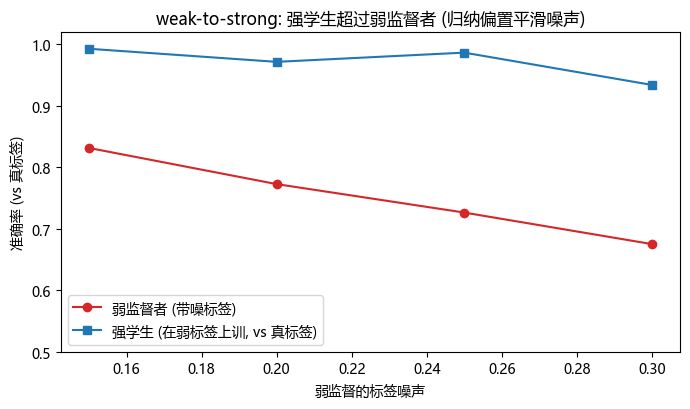

→ 强学生在带噪弱标签上训, 却恢复了真边界, 准确率远超弱监督者 = weak-to-strong generalization。


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
torch.manual_seed(0)
results = []
for noise in [0.15, 0.20, 0.25, 0.30]:
    wa, sa = cp.weak_to_strong_demo(noise=noise, seed=0)
    results.append((noise, wa, sa))
    print(f'噪声 {noise:.0%}: 弱监督者 {wa:.2f} → 强学生 {sa:.2f}  {"✓ 超过 (w2s)" if sa>wa+0.02 else ""}')
noises=[r[0] for r in results]; was=[r[1] for r in results]; sas=[r[2] for r in results]
fig, ax = plt.subplots(figsize=(7,4.2))
ax.plot(noises, was, 'o-', color='C3', label='弱监督者 (带噪标签)')
ax.plot(noises, sas, 's-', color='C0', label='强学生 (在弱标签上训, vs 真标签)')
ax.set_xlabel('弱监督的标签噪声'); ax.set_ylabel('准确率 (vs 真标签)'); ax.set_ylim(0.5,1.02); ax.legend()
ax.set_title('weak-to-strong: 强学生超过弱监督者 (归纳偏置平滑噪声)')
plt.tight_layout(); plt.show()
print('→ 强学生在带噪弱标签上训, 却恢复了真边界, 准确率远超弱监督者 = weak-to-strong generalization。')

## 2. 机制 + 解读

In [3]:
print('''weak-to-strong 的机制 (L3):
  - 弱监督者: 真边界 + 随机噪声 → 标签不稳 (准确率~0.7-0.85)
  - 强学生 (MLP, 平滑归纳偏置): 在带噪标签上训
    → 它"不愿"去拟合零散的噪声 (平滑偏置), 而是学到弱标签背后的"真概念"(斜线边界)
    → 于是恢复真边界, 准确率 ~0.95+ 超过弱监督者
  → 这是 scalable oversight 的一线希望:
    也许弱 (人类) 监督, 能引出强 (超人) 模型的真实能力, 而非被人的错误拖死。

但要诚实 (M9.3):
  - 玩具是干净的 (噪声随机、概念简单); 真实超人模型的"概念"远复杂
  - 弱监督若是"系统性错"(非随机噪声), 强学生会学到系统错 (w2s 失效)
  - 这是 open 问题, 不是已解决''')

weak-to-strong 的机制 (L3):
  - 弱监督者: 真边界 + 随机噪声 → 标签不稳 (准确率~0.7-0.85)
  - 强学生 (MLP, 平滑归纳偏置): 在带噪标签上训
    → 它"不愿"去拟合零散的噪声 (平滑偏置), 而是学到弱标签背后的"真概念"(斜线边界)
    → 于是恢复真边界, 准确率 ~0.95+ 超过弱监督者
  → 这是 scalable oversight 的一线希望:
    也许弱 (人类) 监督, 能引出强 (超人) 模型的真实能力, 而非被人的错误拖死。

但要诚实 (M9.3):
  - 玩具是干净的 (噪声随机、概念简单); 真实超人模型的"概念"远复杂
  - 弱监督若是"系统性错"(非随机噪声), 强学生会学到系统错 (w2s 失效)
  - 这是 open 问题, 不是已解决


## 3. 反思 (12.6 收口)

你做了 weak-to-strong 玩具。带走:
- **scalable oversight**: 模型 > 人时怎么监督 (对齐根本挑战)。
- **weak-to-strong**: 弱监督 (带噪) 能引出强学生超过它 (归纳偏置平滑噪声) — 一线希望。
- 与 interp 互补: 行为监督 (w2s/CoT) 给规模, 机制 interp 给可信 (L3)。

> **M12.6 收口**: CoT 不一定忠实 (偏置敏感性实测高); CoT 监控脆弱; scalable oversight (w2s); 欺骗检测靠 interp。
> **交棒 M12.7「interp-graduation」**: Module 12 capstone — 对一个模型做**完整** interp 解剖 (探针→patching→SAE→电路) + interp×reasoning 研究 idea 卡。下一专题 `interp-graduation`。